In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'x-large',
         'axes.titlesize':'x-large',
         'xtick.labelsize':'x-large',
         'ytick.labelsize':'x-large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
zbest_path = '/global/cfs/cdirs/desi/users/rongpu/spectro/sv1/alltiles_LRGzinfo_mw_trans_added.fits'
tmp = fitsio.read(zbest_path, columns=['TARGETS', 'subset'])
idx = np.where((tmp['subset']=='deep') & (tmp['TARGETS']=='QSO+LRG'))[0]
zbest = Table(fitsio.read(zbest_path, rows=idx))
print(len(zbest))
print(len(np.unique(zbest['TARGETID'])))

34868
34702


In [4]:
# # Print summary of the tiles
# t = Table()
# t['TILEID'], t['count'] = np.unique(zbest['TILEID'], return_counts=True)
# t['efftime'] = 0
# t['n_exp'] = 0
# for index, tileid in enumerate(t['TILEID']):
#     mask = zbest['TILEID']==tileid
#     t['n_exp'][index] = np.max(zbest['COADD_NUMEXP'][mask])
#     t['efftime'][index] = np.max(zbest['EFFTIME_DARK'][mask])
# t

In [4]:
# Remove FIBERSTATUS!=0 fibers
mask = zbest['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Remove "no data" fibers
mask = zbest['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
zbest = zbest[mask]

# Require a minimum depth for the deep coadd
min_depth = 3000.
mask = zbest['EFFTIME_DARK']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]

print(len(zbest))

FIBERSTATUS 29372 5496 0.1576230354479752
No data 29370 2 6.809206046574969e-05
Min depth 24255 5115 0.8258426966292135
24255


In [5]:
# Ting-Wen's quality cuts
mask = zbest['DELTACHI2']>20
mask &= zbest['Z']<1.4

mask &= zbest['ZWARN']==0
print('Quality cuts', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
zbest = zbest[mask]
print(len(zbest))

Quality cuts 23562 693 0.9714285714285714
23562


__Add MEDIUM and WISE masks and require NOBS>=2__

In [20]:
maskbits = [1, 8, 11, 12, 13]
min_nobs = 2

mask_clean = np.ones(len(zbest), dtype=bool)
for bit in maskbits:
    mask_clean &= (zbest['MASKBITS'] & 2**bit)==0
print(np.sum(~mask_clean)/len(mask_clean))

# mask_clean &= (zbest['NOBS_G']>=min_nobs) & (zbest['NOBS_R']>=min_nobs) & (zbest['NOBS_Z']>=min_nobs)
# print(np.sum(~mask_clean)/len(mask_clean))

zbest = zbest[mask_clean]

0.07830404889228419


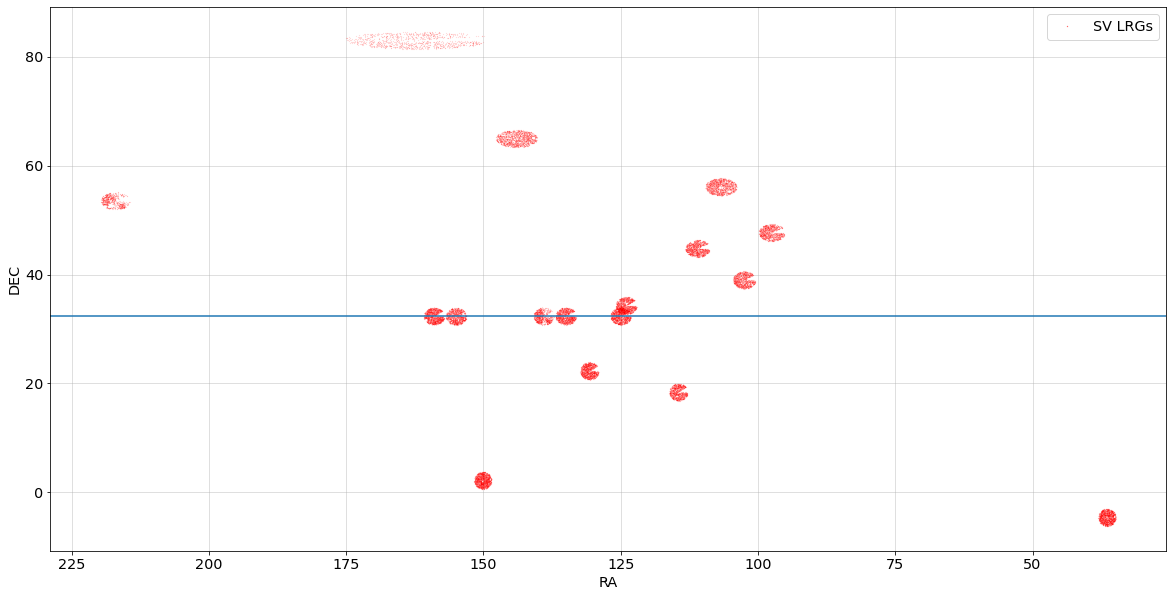

In [50]:
plt.figure(figsize=(20, 10))
plt.plot(zbest['TARGET_RA'], zbest['TARGET_DEC'], 'r.', ms=.1, label='SV LRGs')
plt.xlabel('RA')
plt.ylabel('DEC')
plt.legend(loc='upper right', markerscale=5)
plt.axhline(32.375)
plt.grid(alpha=0.5)
plt.gca().invert_xaxis()
plt.show()

In [22]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    zbest['gmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zmag'] = 22.5 - 2.5*np.log10(zbest['FLUX_Z']/zbest['MW_TRANSMISSION_Z'])
    zbest['w1mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W1']/zbest['MW_TRANSMISSION_W1'])
    zbest['w2mag'] = 22.5 - 2.5*np.log10(zbest['FLUX_W2']/zbest['MW_TRANSMISSION_W2'])
    zbest['gfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_G']/zbest['MW_TRANSMISSION_G'])
    zbest['rfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_R']/zbest['MW_TRANSMISSION_R'])
    zbest['zfibermag'] = 22.5 - 2.5*np.log10(zbest['FIBERFLUX_Z']/zbest['MW_TRANSMISSION_Z'])

In [23]:
gmag = zbest['gmag']
rmag = zbest['rmag']
zmag = zbest['zmag']
w1mag = zbest['w1mag']
w2mag = zbest['w2mag']
rfibermag = zbest['rfibermag']
zfibermag = zbest['zfibermag']
gaia_g = zbest['GAIA_PHOT_G_MEAN_MAG']

mask_north = zbest['PHOTSYS']=='N'
mask_south = zbest['PHOTSYS']=='S'

In [87]:
# Changelog (v1.3):
# - Add GAIA_G>18 cut
# - Revised low-z (g-r vs r-W1) cuts from Jeff (same north and south cuts)
# - Shift the low-z cut intercept by 0.1 in the north (decreasing the density), to account for the north vs south difference
# - Shift the sliding IR cut intercept by 0.05*1.8 (increasing the density), to match the optical target density
# - Replace the low-z middle cut with a horizontal g-r>1.3 cut

# mask_north = cat['PHOTSYS']=='N'
# mask_south = cat['PHOTSYS']=='S'

#################### Updated optical selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_north = lrg_mask.copy()

lrg_opt = lrg_opt_south | lrg_opt_north
print(np.sum(lrg_opt))

#################### Updated IR selection ####################

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.5)                   # faint limit

lrg_mask &= rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_north = lrg_mask.copy()

lrg_ir = lrg_ir_south | lrg_ir_north
print(np.sum(lrg_ir))

5913
6117


In [52]:
lrg_sv = (zbest['SV1_DESI_TARGET'] & 2**0>0)

# lrg_opt = zbest['SV1_DESI_TARGET'] & 2**3>0
# lrg_ir = zbest['SV1_DESI_TARGET'] & 2**4>0
# print(np.sum(lrg_opt))
# print(np.sum(lrg_ir))
# print(np.sum(lrg_sv))
# print()

ts_qso = (zbest['SV1_DESI_TARGET'] & 2**2>0)
print(np.sum(ts_qso))
print(np.sum(ts_qso & lrg_sv))
print(np.sum(ts_qso & lrg_opt))

474
474
39


In [53]:
from matplotlib.ticker import FormatStrFormatter
sys.path.append(os.path.expanduser('~/git/desi-lrg-selection'))
import plotting_scripts as lrg_plot
import importlib
importlib.reload(lrg_plot)

<module 'plotting_scripts' from '/global/homes/r/rongpu/git/desi-lrg-selection/plotting_scripts.py'>

In [54]:
# numbers from another notebook
n_opt_tot = 6228964
n_ir_tot = 6252619
area_tot = 10109.0

area_opt_south = np.sum(lrg_opt_south)/n_opt_tot * area_tot
area_ir_south = np.sum(lrg_ir_south)/n_ir_tot * area_tot
area_opt_north = np.sum(lrg_opt_north)/n_opt_tot * area_tot
area_ir_north = np.sum(lrg_ir_north)/n_ir_tot * area_tot
print(area_opt_south, area_ir_south)
print(area_opt_north, area_ir_north)

4.201895623687366 4.31997630075825
5.431996901657107 5.633053843022622


South


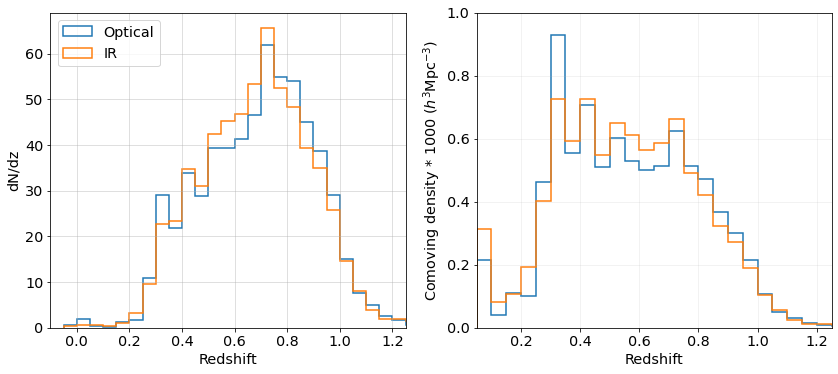

In [55]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_south)))/area_opt_south, histtype='step', label='Optical')
axes[0].hist(zbest['Z'][lrg_ir_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_south)))/area_ir_south, histtype='step', label='IR')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_south], area=area_opt_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

North


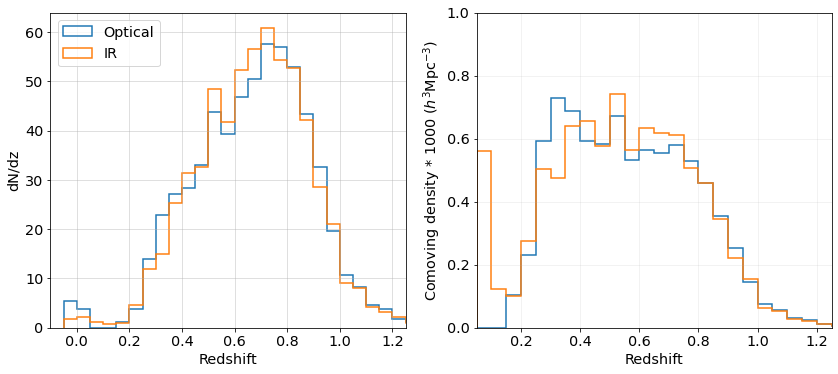

In [56]:
print('North')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_north)))/area_opt_north, histtype='step', label='Optical')
axes[0].hist(zbest['Z'][lrg_ir_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_north)))/area_ir_north, histtype='step', label='IR')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_north], area=area_opt_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

-----
## Remove IR excess

In [57]:
# Remove IR excess
lrg_ir_south &= (zmag - w1mag < 1.05 * (rmag-zmag) - 0.08)
lrg_ir_north &= (zmag - w1mag < 1.05 * (rmag-zmag) - 0.08)

South


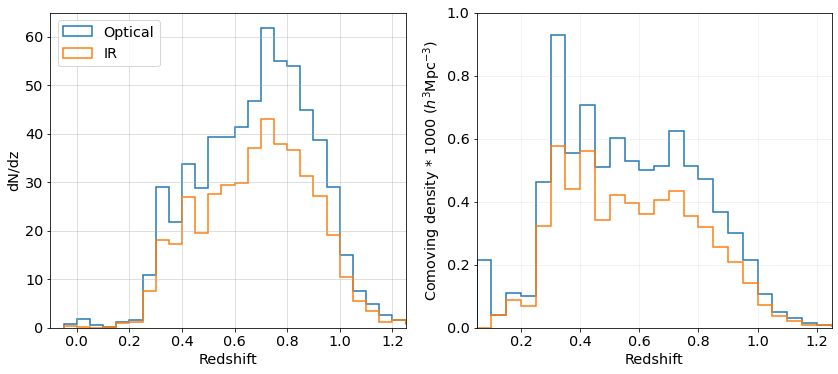

In [58]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_south)))/area_opt_south, histtype='step', label='Optical')
axes[0].hist(zbest['Z'][lrg_ir_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_south)))/area_ir_south, histtype='step', label='IR')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_south], area=area_opt_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

North


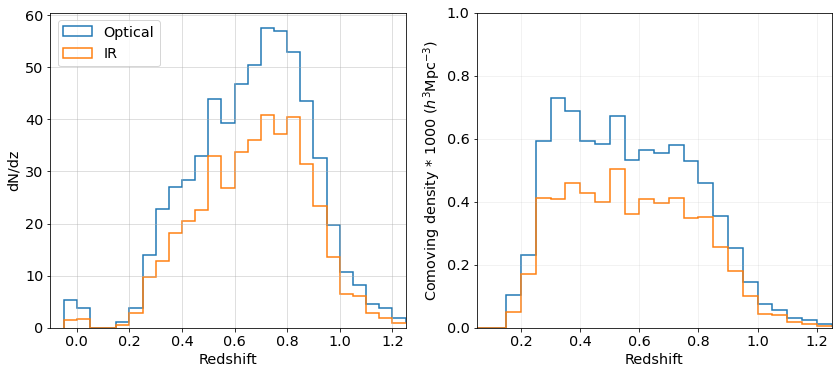

In [59]:
print('North')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_north)))/area_opt_north, histtype='step', label='Optical')
axes[0].hist(zbest['Z'][lrg_ir_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_north)))/area_ir_north, histtype='step', label='IR')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_north], area=area_opt_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

---------
# IR high-z extension

In [132]:
# zfiber & sliding cut extension; +200 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.27) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.37) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.29
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_highz_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask_sliding = rmag - w1mag > (w1mag - 17.23) * 1.8 # sliding IR cut
lrg_mask_sliding &= rmag - w1mag > (w1mag - 16.33) * 1.  # low-z sliding IR cut
lrg_mask_sliding |= rmag - w1mag > 3.35
lrg_mask &= lrg_mask_sliding

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_ir_highz_north = lrg_mask.copy()

lrg_ir_highz = lrg_ir_highz_south | lrg_ir_highz_north
print(np.sum(lrg_ir_highz))

8175


In [133]:
lrg_ir_highz_subset = lrg_ir_highz & (~lrg_ir)
lrg_ir_highz_subset_north = lrg_ir_highz_north & (~lrg_ir_north)
lrg_ir_highz_subset_south = lrg_ir_highz_south & (~lrg_ir_south)
print(np.sum(lrg_ir_highz_subset_north))
print(np.sum(lrg_ir_highz_subset_south))

1177
881


In [134]:
# print('South')
# fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
# bins = np.arange(-0.05, 1.45, 0.05)
# axes[0].hist(zbest['Z'][lrg_ir_highz_south], bins=bins, lw=1.5,
#              weights=np.ones(int(np.sum(lrg_ir_highz_south)))/area_ir_south, histtype='step', label='High-z')
# axes[0].hist(zbest['Z'][lrg_ir_south], bins=bins, lw=1.5,
#              weights=np.ones(int(np.sum(lrg_ir_south)))/area_ir_south, histtype='step', label='Baseline IR')
# axes[0].set_xlabel('Redshift')
# axes[0].set_ylabel('dN/dz')
# axes[0].set_xlim(-0.1, 1.25)
# axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
# axes[0].grid(alpha=0.5)
# axes[0].legend(loc='upper left')
# # axes[0].set_ylim(top=30)
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_highz_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
# axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

South


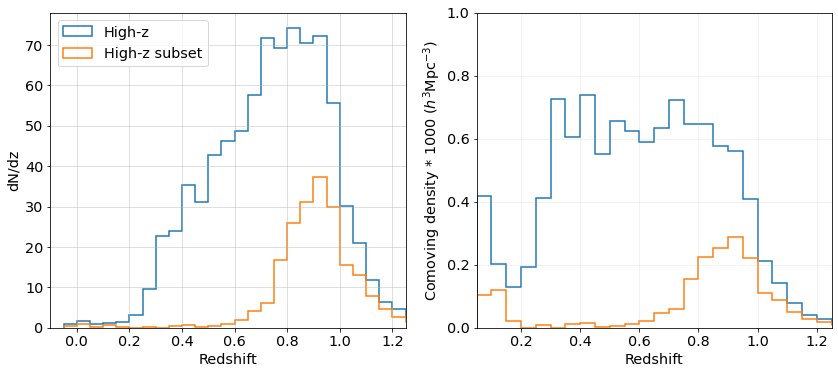

In [135]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_ir_highz_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_highz_south)))/area_ir_south, histtype='step', label='High-z')
axes[0].hist(zbest['Z'][lrg_ir_highz_subset_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_highz_subset_south)))/area_ir_south, histtype='step', label='High-z subset')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_highz_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_highz_subset_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

north


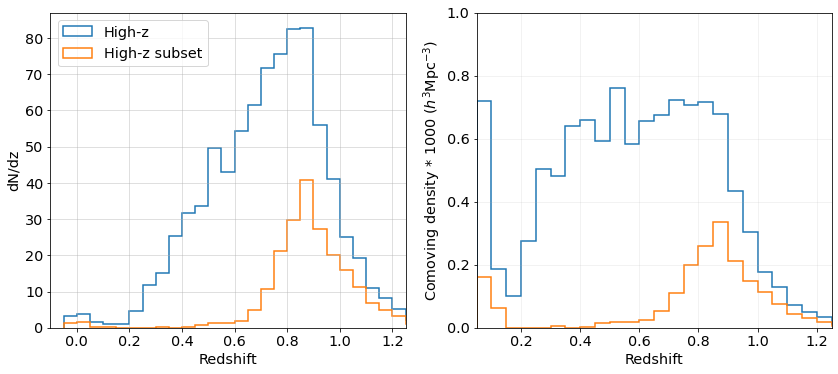

In [136]:
print('north')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_ir_highz_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_highz_north)))/area_ir_north, histtype='step', label='High-z')
axes[0].hist(zbest['Z'][lrg_ir_highz_subset_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_ir_highz_subset_north)))/area_ir_north, histtype='step', label='High-z subset')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_highz_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_ir_highz_subset_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

---------
# Optical high-z extension

In [113]:
# zfiber extension; +100 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.83) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_highz_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask &= rmag - zmag > (zmag - 16.79) * 0.45       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_highz_north = lrg_mask.copy()

lrg_opt_highz = lrg_opt_highz_south | lrg_opt_highz_north
print(np.sum(lrg_opt_highz))

lrg1 = lrg_opt_highz.copy()

6939


In [114]:
lrg_opt_highz_subset = lrg_opt_highz & (~lrg_opt)
lrg_opt_highz_subset_north = lrg_opt_highz_north & (~lrg_opt_north)
lrg_opt_highz_subset_south = lrg_opt_highz_south & (~lrg_opt_south)
print(np.sum(lrg_opt_highz_subset_north))
print(np.sum(lrg_opt_highz_subset_south))

540
486


South
South


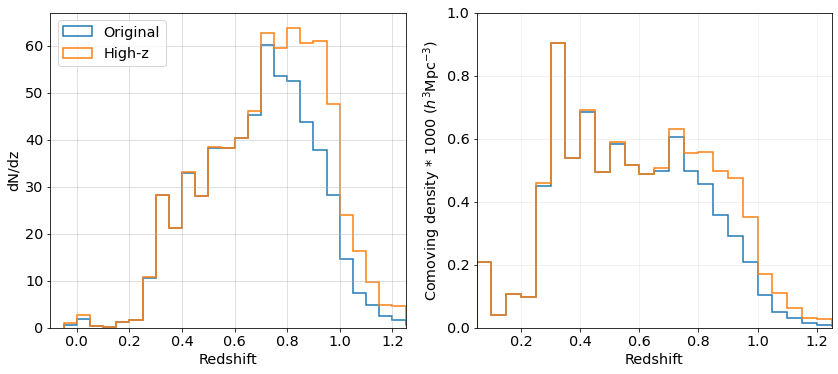

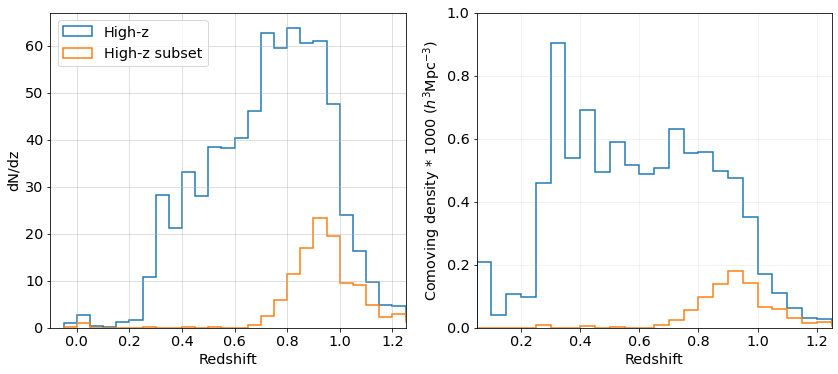

In [116]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_south)))/area_ir_south, histtype='step', label='Original')
axes[0].hist(zbest['Z'][lrg_opt_highz_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_south)))/area_ir_south, histtype='step', label='High-z')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_highz_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_south)))/area_ir_south, histtype='step', label='High-z')
axes[0].hist(zbest['Z'][lrg_opt_highz_subset_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_subset_south)))/area_ir_south, histtype='step', label='High-z subset')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_subset_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

In [118]:
# zfiber extension; +150 targets/sq.deg.

# South
lrg_mask = mask_south.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask &= (rmag - zmag > 1.8) | (rmag - zmag > (zmag - 16.83) * 0.45)       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.80) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.13)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_highz_south = lrg_mask.copy()

# North
lrg_mask = mask_north.copy()
lrg_mask &= zmag - w1mag > 0.8 * (rmag-zmag) - 0.6  # non-stellar cut
lrg_mask &= (zfibermag < 21.7)                   # faint limit

lrg_mask &= (rmag - zmag > 1.8) | (rmag - zmag > (zmag - 16.79) * 0.45)       # sliding optical cut
lrg_mask &= rmag - zmag > (zmag - 13.76) * 0.19       # low-z sliding optical cut

mask_lowz = (gmag-rmag > 1.3) & ( (gmag-rmag) > -1.55*(rmag-w1mag)+3.23)
mask_lowz |= (rmag-w1mag > 1.8)
lrg_mask &= mask_lowz

mask_bright = (gaia_g!=0) & (gaia_g<18)
lrg_mask &= (~mask_bright)

lrg_opt_highz_north = lrg_mask.copy()

lrg_opt_highz = lrg_opt_highz_south | lrg_opt_highz_north
print(np.sum(lrg_opt_highz))

lrg1 = lrg_opt_highz.copy()

7485


In [120]:
lrg_opt_highz_subset = lrg_opt_highz & (~lrg_opt)
lrg_opt_highz_subset_north = lrg_opt_highz_north & (~lrg_opt_north)
lrg_opt_highz_subset_south = lrg_opt_highz_south & (~lrg_opt_south)
print(np.sum(lrg_opt_highz_subset_north))
print(np.sum(lrg_opt_highz_subset_south))

893
679


South
South


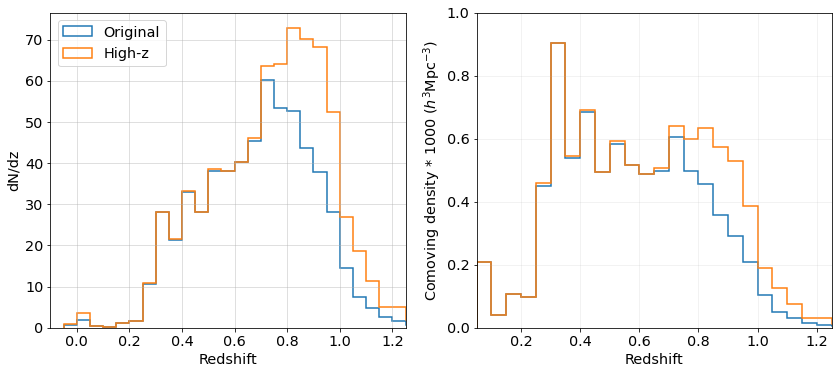

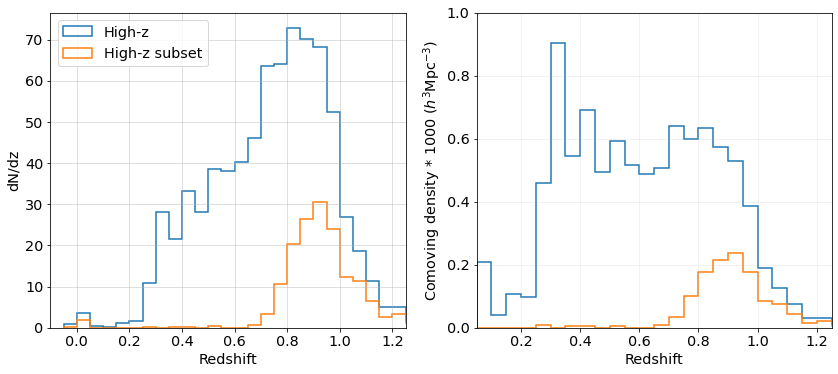

In [121]:
print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_south)))/area_ir_south, histtype='step', label='Original')
axes[0].hist(zbest['Z'][lrg_opt_highz_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_south)))/area_ir_south, histtype='step', label='High-z')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

print('South')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_highz_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_south)))/area_ir_south, histtype='step', label='High-z')
axes[0].hist(zbest['Z'][lrg_opt_highz_subset_south], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_subset_south)))/area_ir_south, histtype='step', label='High-z subset')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_subset_south], area=area_ir_south, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

north
north


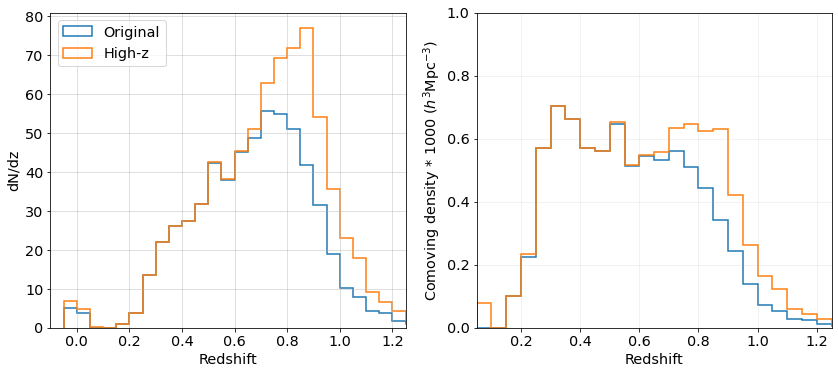

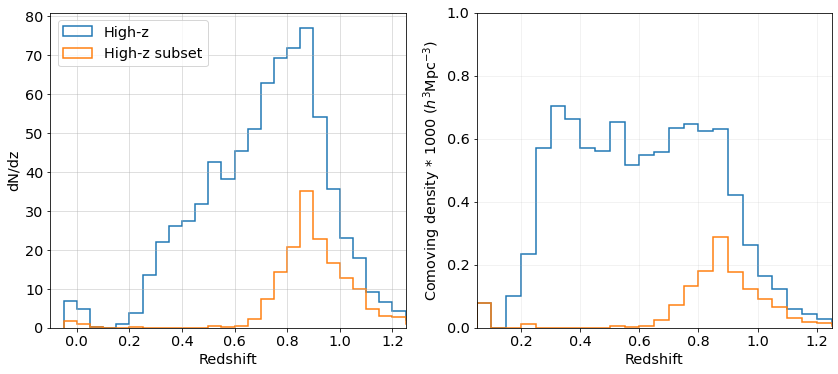

In [122]:
print('north')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_north)))/area_ir_north, histtype='step', label='Original')
axes[0].hist(zbest['Z'][lrg_opt_highz_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_north)))/area_ir_north, histtype='step', label='High-z')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

print('north')
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
bins = np.arange(-0.05, 1.45, 0.05)
axes[0].hist(zbest['Z'][lrg_opt_highz_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_north)))/area_ir_north, histtype='step', label='High-z')
axes[0].hist(zbest['Z'][lrg_opt_highz_subset_north], bins=bins, lw=1.5,
             weights=np.ones(int(np.sum(lrg_opt_highz_subset_north)))/area_ir_north, histtype='step', label='High-z subset')
axes[0].set_xlabel('Redshift')
axes[0].set_ylabel('dN/dz')
axes[0].set_xlim(-0.1, 1.25)
axes[0].yaxis.set_major_formatter(FormatStrFormatter('%.0f'))
axes[0].grid(alpha=0.5)
axes[0].legend(loc='upper left')
# axes[0].set_ylim(top=30)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)
axes[1] = lrg_plot.plot_comoving_density(zbest['Z'][lrg_opt_highz_subset_north], area=area_ir_north, zmin=0.05, zmax=1.45, dz=0.05, axis=[0.05, 1.25, 0, 1.], xlabel='Redshift', show=False, lw=1.5)

In [123]:
# Full SV selection in South

# Optical

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8  # non-stellar cut
lrg_mask &= ((zmag < 21.0) | (zfibermag < 22.0))   # faint limit

mask_red = (gmag - w1mag > 2.5) & (gmag - rmag > 1.3) # low-z cut
mask_red |= (rmag-w1mag) > 1.7                        # ignore low-z cut for faint objects
lrg_mask &= mask_red

# straight cut for low-z:
lrg_mask_lowz = zmag < 20.2
lrg_mask_lowz &= rmag - zmag > (zmag - 17.20) * 0.45
lrg_mask_lowz &= rmag - zmag > (zmag - 14.17) * 0.19
# curved sliding cut for high-z:
lrg_mask_highz = zmag >= 20.2
lrg_mask_highz &= (((zmag - 23.18) / 1.3)**2 + (rmag - zmag + 2.5)**2 > 4.48**2)

lrg_mask &= (lrg_mask_lowz | lrg_mask_highz)

lrg_mask_optical_sv_south = lrg_mask.copy()

# IR

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8  # non-stellar cut
lrg_mask &= ((zmag < 21.0) | (zfibermag < 22.0))   # faint limit
lrg_mask &= (rmag - w1mag > 1.0)                   # Low-z cut

lrg_mask_slide = rmag - w1mag > (w1mag - 17.48) * 1.8  # sliding IR cut
lrg_mask_slide |= (rmag - w1mag > 3.1)

lrg_mask &= lrg_mask_slide

lrg_mask_ir_sv_south = lrg_mask.copy()

################################################################################################

# Full SV selection in North

# Optical

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8  # non-stellar cut
lrg_mask &= ((zmag < 21.0) | (zfibermag < 22.0))   # faint limit

mask_red = (gmag - w1mag > 2.57) & (gmag - rmag > 1.35) # low-z cut
mask_red |= (rmag-w1mag) > 1.75                         # ignore low-z cut for faint objects
lrg_mask &= mask_red

# straight cut for low-z:
lrg_mask_lowz = zmag < 20.2
lrg_mask_lowz &= rmag - zmag > (zmag - 17.17) * 0.45
lrg_mask_lowz &= rmag - zmag > (zmag - 14.14) * 0.19
# curved sliding cut for high-z:
lrg_mask_highz = zmag >= 20.2
lrg_mask_highz &= (((zmag - 23.15) / 1.3)**2 + (rmag - zmag + 2.5)**2 > 4.48**2)

lrg_mask &= (lrg_mask_lowz | lrg_mask_highz)

lrg_mask_optical_sv_north = lrg_mask.copy()

# IR

lrg_mask = zmag - w1mag > 0.8 * (rmag-zmag) - 0.8 # non-stellar cut
lrg_mask &= ((zmag < 21.0) | (zfibermag < 22.0))  # faint limit
lrg_mask &= (rmag - w1mag > 1.03)                 # Low-z cut

lrg_mask_slide = rmag - w1mag > (w1mag - 17.44) * 1.8  # sliding IR cut
lrg_mask_slide |= (rmag - w1mag > 3.1)

lrg_mask &= lrg_mask_slide

lrg_mask_ir_sv_north = lrg_mask.copy()